/opt/anaconda3/envs/en1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/en1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/en1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/en1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


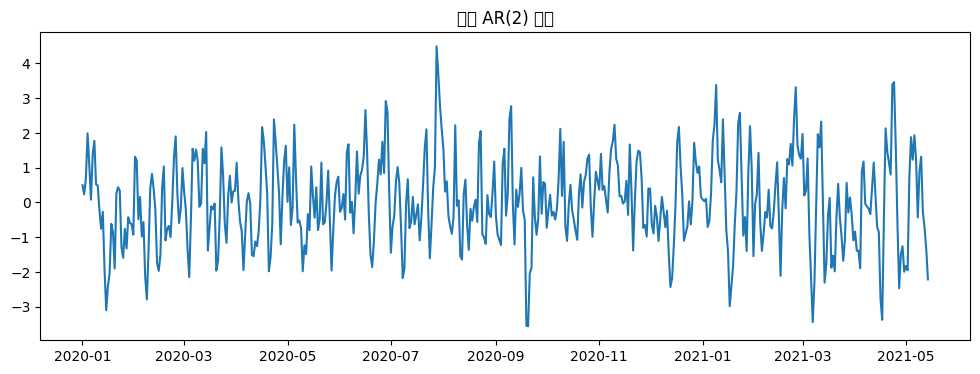

/var/folders/vf/f1yl8qs536s4hz0355b67w0c0000gn/T/ipykernel_12946/2885055246.py:37: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/envs/en1/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


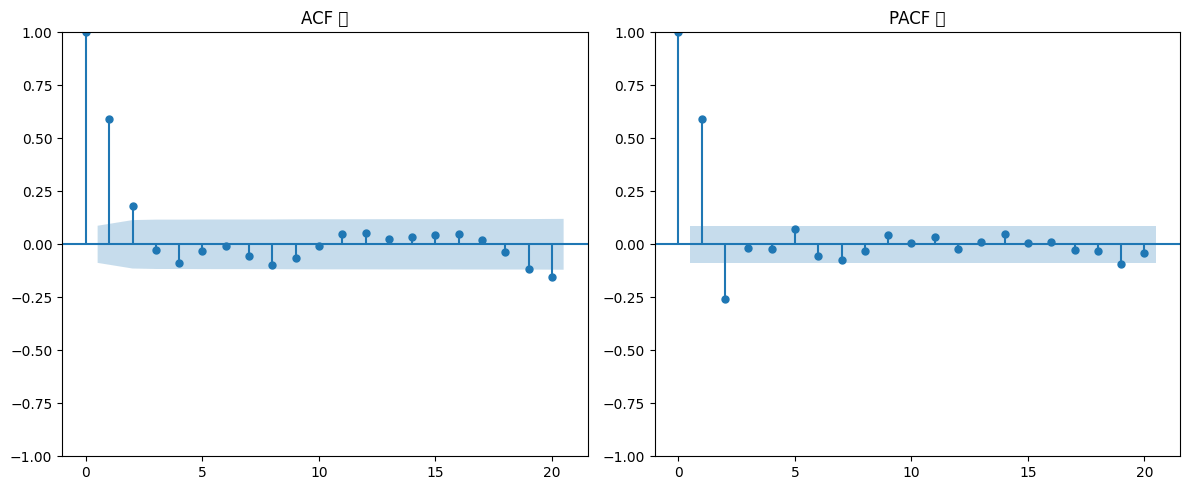

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess

# 构造一个 AR(2) 模型示例：假设系数为 [0.75, -0.25]
ar_params = np.array([0.75, -0.25])
# 注意：构造AR过程时需要传入反向系数，1 - 0.75*L + 0.25*L^2
ar = np.r_[1, -ar_params]
ma = np.array([1])
arma_process = ArmaProcess(ar, ma)

# 生成模拟数据
np.random.seed(42)
sample_size = 500
simulated_data = arma_process.generate_sample(nsample=sample_size)

# 将数据转换为 pandas.Series
dates = pd.date_range(start="2020-01-01", periods=sample_size, freq='D')
series = pd.Series(simulated_data, index=dates)

# 绘制时序图
plt.figure(figsize=(12,4))
plt.plot(series)
plt.title("模拟 AR(2) 数据")
plt.show()

# 绘制 ACF 和 PACF 图
plt.figure(figsize=(12,5))
plt.subplot(121)
plot_acf(series, lags=20, ax=plt.gca())
plt.title("ACF 图")
plt.subplot(122)
plot_pacf(series, lags=20, ax=plt.gca())
plt.title("PACF 图")
plt.tight_layout()
plt.show()
